<a href="https://colab.research.google.com/github/altafmadni/Data_Projects/blob/main/Project%202/ChatGPT_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
url = "/content/ChatGPT_Reviews_200000_Updated.xlsx"
df= pd.read_excel(url)

In [5]:
df.head()

,Review_ID,Review,Rating,Review_Date
0,1,Mast app hai. Daily use karta hu for office wo...,5,2025-09-27
1,2,Good app overall but sometimes the responses a...,3,2024-04-18
2,3,Mast app hai. Daily use karta hu for office wo...,4,2024-08-25
3,4,"Very useful for Python, SQL and Power BI learn...",5,2025-11-22
4,5,Helped me prepare for interviews. The explanat...,5,2024-08-13


In [6]:
df.columns

Index(['Review_ID', 'Review', 'Rating', 'Review_Date'], dtype='object')

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.isnull().sum()

,0
review_id,0
review,6
rating,0
review_date,0


In [9]:
df['review'].fillna(" ", inplace = True)

/tmp/ipykernel_1523/2195683206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna(" ", inplace = True)


In [10]:
df.isna().sum()

,0
review_id,0
review,0
rating,0
review_date,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   review_id    200000 non-null  int64 
 1   review       200000 non-null  object
 2   rating       200000 non-null  int64 
 3   review_date  200000 non-null  object
dtypes: int64(2), object(2)
memory usage: 6.1+ MB


In [12]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    200000 non-null  int64         
 1   review       200000 non-null  object        
 2   rating       200000 non-null  int64         
 3   review_date  200000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 6.1+ MB


## Sentiment Analysis


In [14]:
def get_sentiment_polarity(text):
  if pd.isna(text) or text == "":
    return 0
  blob = TextBlob(text)
  return blob.sentiment.polarity

df['sentiment_polarity'] = df['review'].apply(get_sentiment_polarity)

In [15]:
display(df.head())

,review_id,review,rating,review_date,sentiment_polarity
0,1,Mast app hai. Daily use karta hu for office wo...,5,2025-09-27,0.080000
1,2,Good app overall but sometimes the responses a...,3,2024-04-18,0.150000
2,3,Mast app hai. Daily use karta hu for office wo...,4,2024-08-25,0.080000
3,4,"Very useful for Python, SQL and Power BI learn...",5,2025-11-22,0.345000
4,5,Helped me prepare for interviews. The explanat...,5,2024-08-13,0.216667


In [16]:
def get_sentiment_category(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_polarity'].apply(get_sentiment_category)

In [17]:
df.head()

,review_id,review,rating,review_date,sentiment_polarity,sentiment_category
0,1,Mast app hai. Daily use karta hu for office wo...,5,2025-09-27,0.080000,Neutral
1,2,Good app overall but sometimes the responses a...,3,2024-04-18,0.150000,Positive
2,3,Mast app hai. Daily use karta hu for office wo...,4,2024-08-25,0.080000,Neutral
3,4,"Very useful for Python, SQL and Power BI learn...",5,2025-11-22,0.345000,Positive
4,5,Helped me prepare for interviews. The explanat...,5,2024-08-13,0.216667,Positive


In [19]:
def get_sentiment_subjectivity(text):
  if pd.isna(text) or text == "":
    return 0
  blob = TextBlob(text)
  return blob.sentiment.subjectivity

df['sentiment_subjectivity'] = df['review'].apply(get_sentiment_subjectivity)

In [20]:
df.head()

,review_id,review,rating,review_date,sentiment_polarity,sentiment_category,sentiment_subjectivity
0,1,Mast app hai. Daily use karta hu for office wo...,5,2025-09-27,0.080000,Neutral,0.270000
1,2,Good app overall but sometimes the responses a...,3,2024-04-18,0.150000,Positive,0.283333
2,3,Mast app hai. Daily use karta hu for office wo...,4,2024-08-25,0.080000,Neutral,0.270000
3,4,"Very useful for Python, SQL and Power BI learn...",5,2025-11-22,0.345000,Positive,0.050000
4,5,Helped me prepare for interviews. The explanat...,5,2024-08-13,0.216667,Positive,0.595238


## Visualize Sentiment Analysis

In [23]:
sentiment_counts

,count
sentiment_category,
Positive,142809
Neutral,47960
Negative,9231


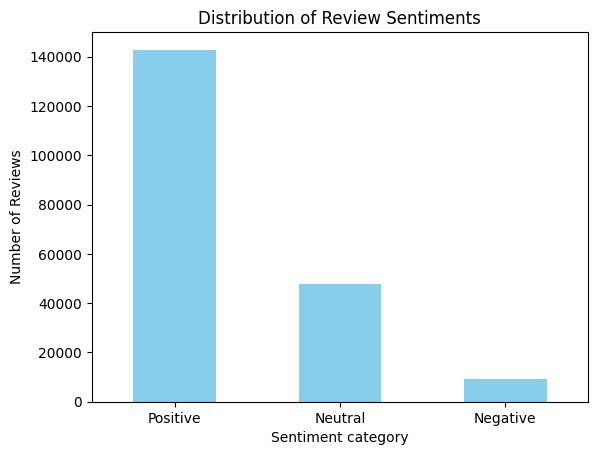

In [22]:
sentiment_counts  = df['sentiment_category'].value_counts()

sentiment_counts.plot(kind = 'bar', color = 'skyblue')
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation = 0)
plt.show()


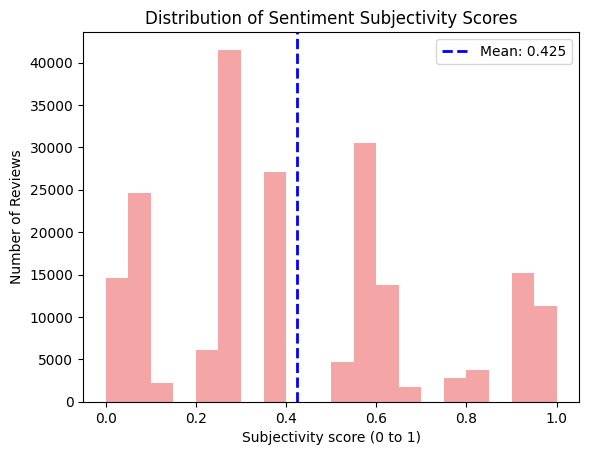

In [24]:
plt.hist(df['sentiment_subjectivity'], bins = 20, color = 'lightcoral', alpha=0.7)
plt.axvline(df['sentiment_subjectivity'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {df['sentiment_subjectivity'].mean():.3f}')
plt.title('Distribution of Sentiment Subjectivity Scores')
plt.xlabel('Subjectivity score (0 to 1)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.show()

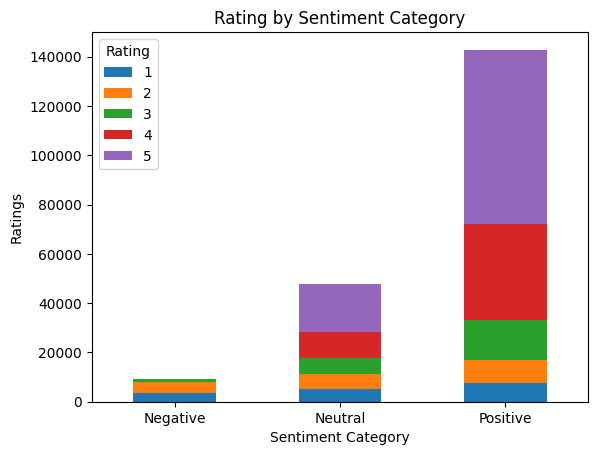

In [33]:
sentiment_rating = df.groupby(['sentiment_category','rating']).size().unstack(fill_value=0)
sentiment_rating.plot(kind  ='bar', stacked = True)
# plt.axvline(df['sentiment_subjectivity'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {df['sentiment_subjectivity'].mean():.3f}')
plt.title('Rating by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.xticks(rotation = 0)
plt.ylabel('Ratings')
plt.legend(title = 'Rating', loc = 'upper left')
plt.show()

## Analyzing Positive Reviews

In [46]:
positive_review = df[df['sentiment_category'] == 'Positive']['review']

In [47]:
positive_review

,review
1,Good app overall but sometimes the responses a...
3,"Very useful for Python, SQL and Power BI learn..."
4,Helped me prepare for interviews. The explanat...
6,After the latest update the responses are slow...
8,Worth it
...,...
199994,Very useful
199995,Helped me prepare for interviews. The explanat...
199996,Decent experience. Useful for learning but I a...
199997,Best AI app I have used. Helped me complete my...


In [39]:
from collections import Counter
all_text = ' '.join(positive_review.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', "", all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases(bigrams and trigrams)
phrases = []

for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

pos_phrases = phrase_freq.most_common(10)


In [41]:
pos_phrases

[('useful for', 30122),
 ('very useful', 26940),
 ('best app', 26730),
 ('for python', 24670),
 ('python sql', 24670),
 ('sql and', 24670),
 ('and power', 24670),
 ('power learning', 24670),
 ('learning worth', 24670),
 ('worth every', 24670)]

## Visualize Positive Features

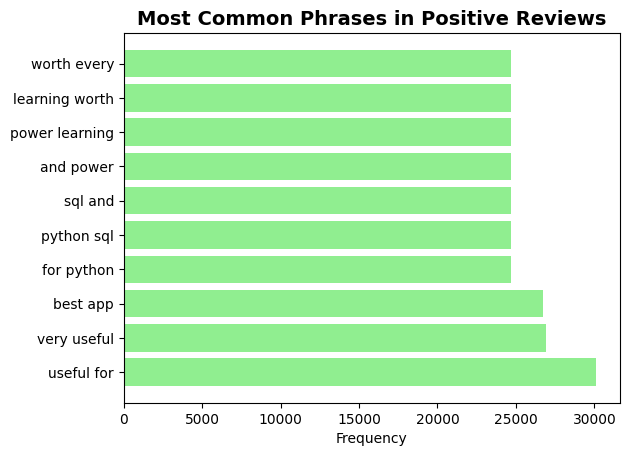

In [42]:
phrases, phrase_counts = zip(*pos_phrases)

plt.barh(range(len(phrases)), phrase_counts, color='lightgreen')
plt.yticks(range(len(phrases)), phrases)

plt.title("Most Common Phrases in Positive Reviews", fontsize = 14, fontweight= 'bold')
plt.xlabel("Frequency")

plt.show()

## Analyzing Negative Reviews

In [44]:
negative_review = df[df['sentiment_category'] == 'Negative']['review']

In [45]:
negative_review

,review
16,Average experience
17,Not accurate
41,Average
56,Bad
65,Bad
...,...
199842,Too slow
199859,Too slow
199972,Average
199977,Waste


In [49]:
from collections import Counter
all_text = ' '.join(negative_review.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', "", all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases(bigrams and trigrams)
phrases = []

for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

neg_phrases = phrase_freq.most_common(10)


In [50]:
neg_phrases

[('too slow', 956),
 ('not accurate', 916),
 ('waste money', 912),
 ('very disappointing', 901),
 ('average experience', 756),
 ('slow waste', 211),
 ('slow average', 206),
 ('slow very', 151),
 ('slow very disappointing', 151),
 ('disappointing waste', 149)]

## Visualize Negative Reviews


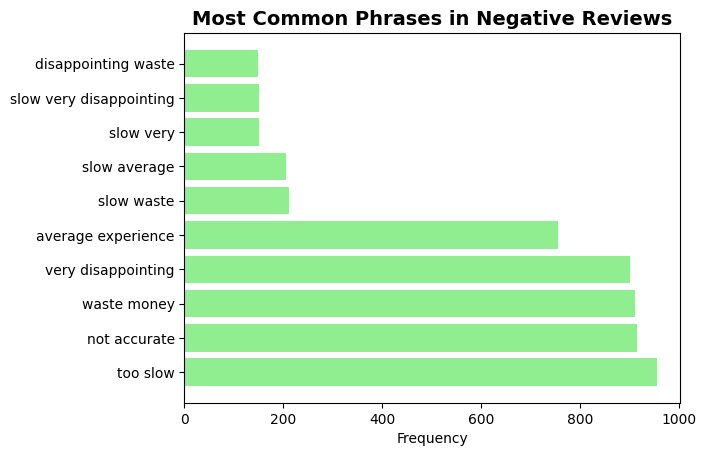

In [51]:
phrases, phrase_counts = zip(*neg_phrases)

plt.barh(range(len(phrases)), phrase_counts, color='lightgreen')
plt.yticks(range(len(phrases)), phrases)

plt.title("Most Common Phrases in Negative Reviews", fontsize = 14, fontweight= 'bold')
plt.xlabel("Frequency")

plt.show()

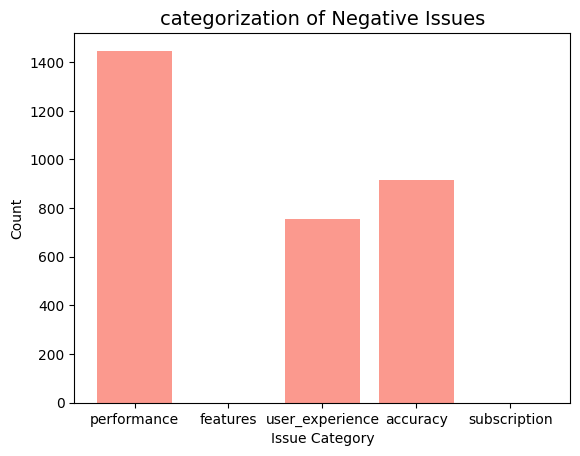

In [53]:
issue_category = {

    "performance": [
        "slow",
        "lag",
        "loading",
        "crash",
        "freeze",
        "delay",
        "buffering",
        "timeout",
        "heating",
        "speed"
    ],

    "features": [
        "voice",
        "image",
        "coding",
        "writing",
        "translation",
        "research",
        "history",
        "search",
        "upload",
        "memory"
    ],

    "user_experience": [
        "interface",
        "design",
        "navigation",
        "layout",
        "simple",
        "friendly",
        "smooth",
        "confusing",
        "responsive",
        "experience"
    ],

    "accuracy": [
        "accurate",
        "incorrect",
        "wrong",
        "error",
        "mistake",
        "hallucination",
        "repetitive",
        "outdated",
        "reliable",
        "relevant"
    ],

    "subscription": [
        "premium",
        "subscription",
        "pricing",
        "payment",
        "refund",
        "billing",
        "renewal",
        "upgrade",
        "trial",
        "expensive"
    ]
}

category_counts = {}

for category, keywords in issue_category.items():
  count = 0
  for  review in negative_review:
    if any(keyword in str(review).lower() for keyword in keywords):
      count += 1
    category_counts[category] = count
categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.bar(categories, counts, color ='salmon', alpha = 0.8)
plt.title('categorization of Negative Issues', fontsize = 14)
plt.xlabel('Issue Category')
plt.ylabel('Count')
plt.show()

## Analyzing Neutral Reviews

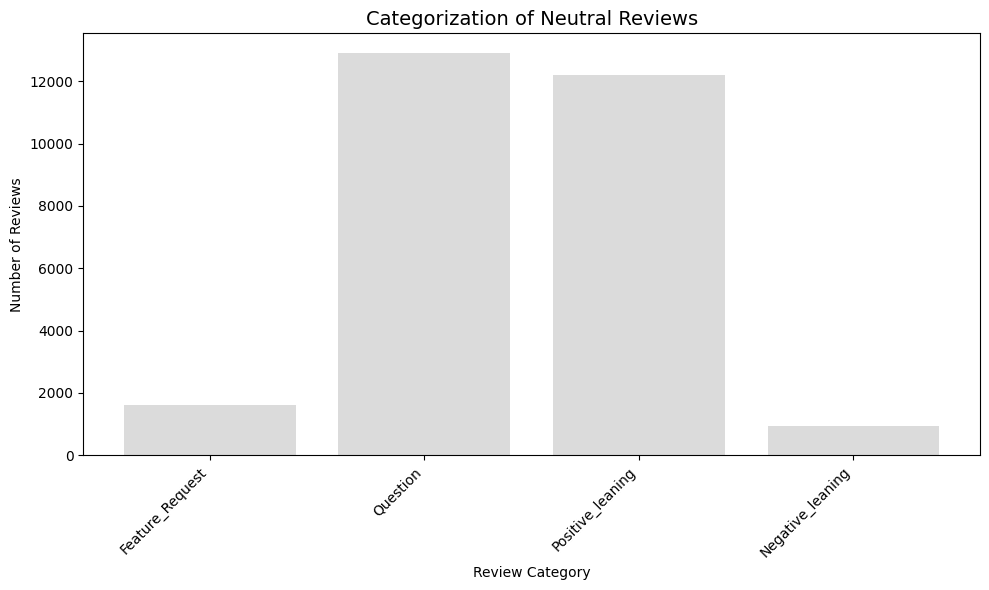

In [59]:
keyword_map = {

    "Feature_Request": [
        "add",
        "include",
        "support",
        "feature",
        "option",
        "allow",
        "provide",
        "implement",
        "improve",
        "update"
    ],

    "Question": [
        "how",
        "why",
        "when",
        "where",
        "what",
        "can",
        "does",
        "is",
        "unable",
        "help"
    ],

    "Positive_leaning": [
        "good",
        "nice",
        "decent",
        "useful",
        "helpful",
        "easy",
        "better",
        "impressive",
        "smooth",
        "satisfied"
    ],

    "Negative_leaning": [
        "slow",
        "bug",
        "issue",
        "error",
        "problem",
        "wrong",
        "poor",
        "difficult",
        "confusing",
        "limited"
    ]
}

# Redefine neutral_review as the previous cell was deleted
neutral_review = df[df['sentiment_category'] == 'Neutral']['review']

neutral_category_counts = {}

for category, keywords in keyword_map.items():
  count = 0
  # Iterate directly over neutral_review (which is already a Series of review texts)
  for review_text in neutral_review:
    if any(keyword in str(review_text).lower() for keyword in keywords):
      count += 1
  neutral_category_counts[category] = count

categories_for_plot = list(neutral_category_counts.keys())
counts_for_plot = list(neutral_category_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(categories_for_plot, counts_for_plot, color='lightgray', alpha=0.8)
plt.title('Categorization of Neutral Reviews', fontsize=14)
plt.xlabel('Review Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Review Evolution over Time


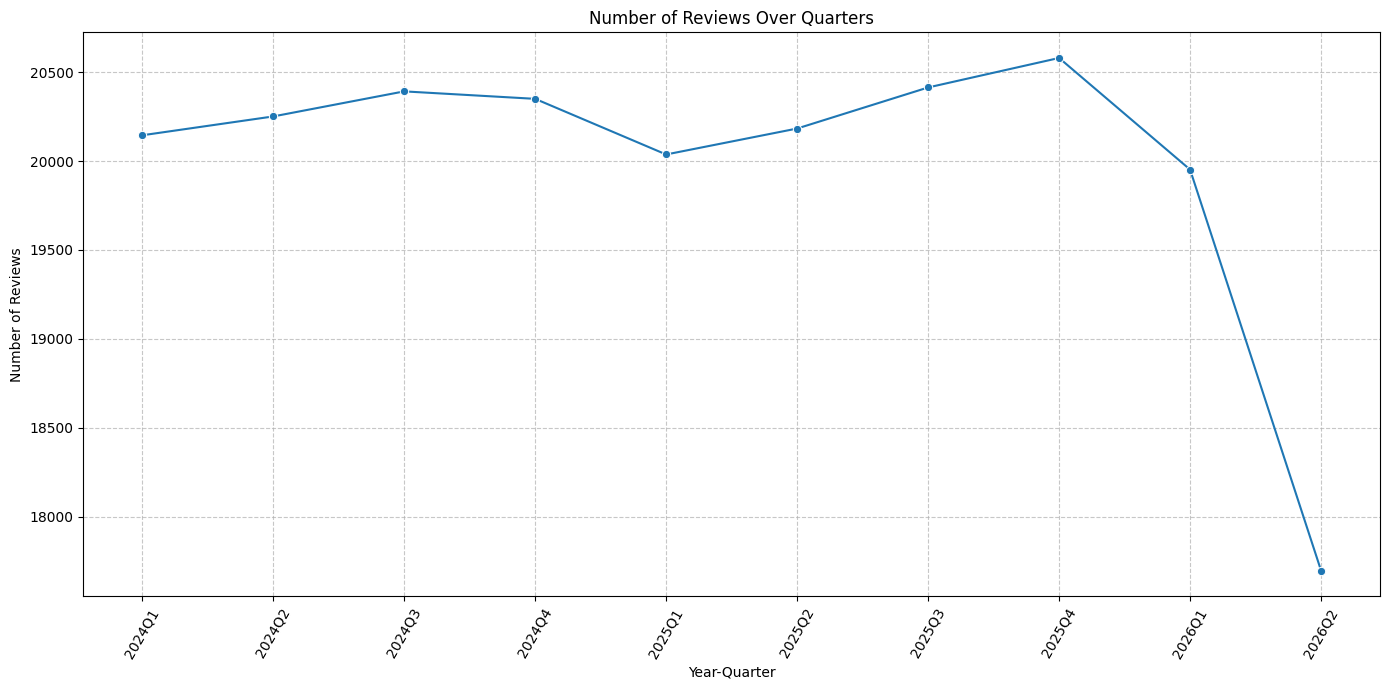

In [62]:
df['year_quarter'] = df['review_date'].dt.to_period('Q')

# Calculate the number of reviews per quarter
reviews_over_quarter = df.groupby('year_quarter').size().reset_index(name='number_of_reviews')

reviews_over_quarter['year_quarter'] = reviews_over_quarter['year_quarter'].astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(x='year_quarter', y='number_of_reviews', data=reviews_over_quarter, marker='o')
plt.title('Number of Reviews Over Quarters')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

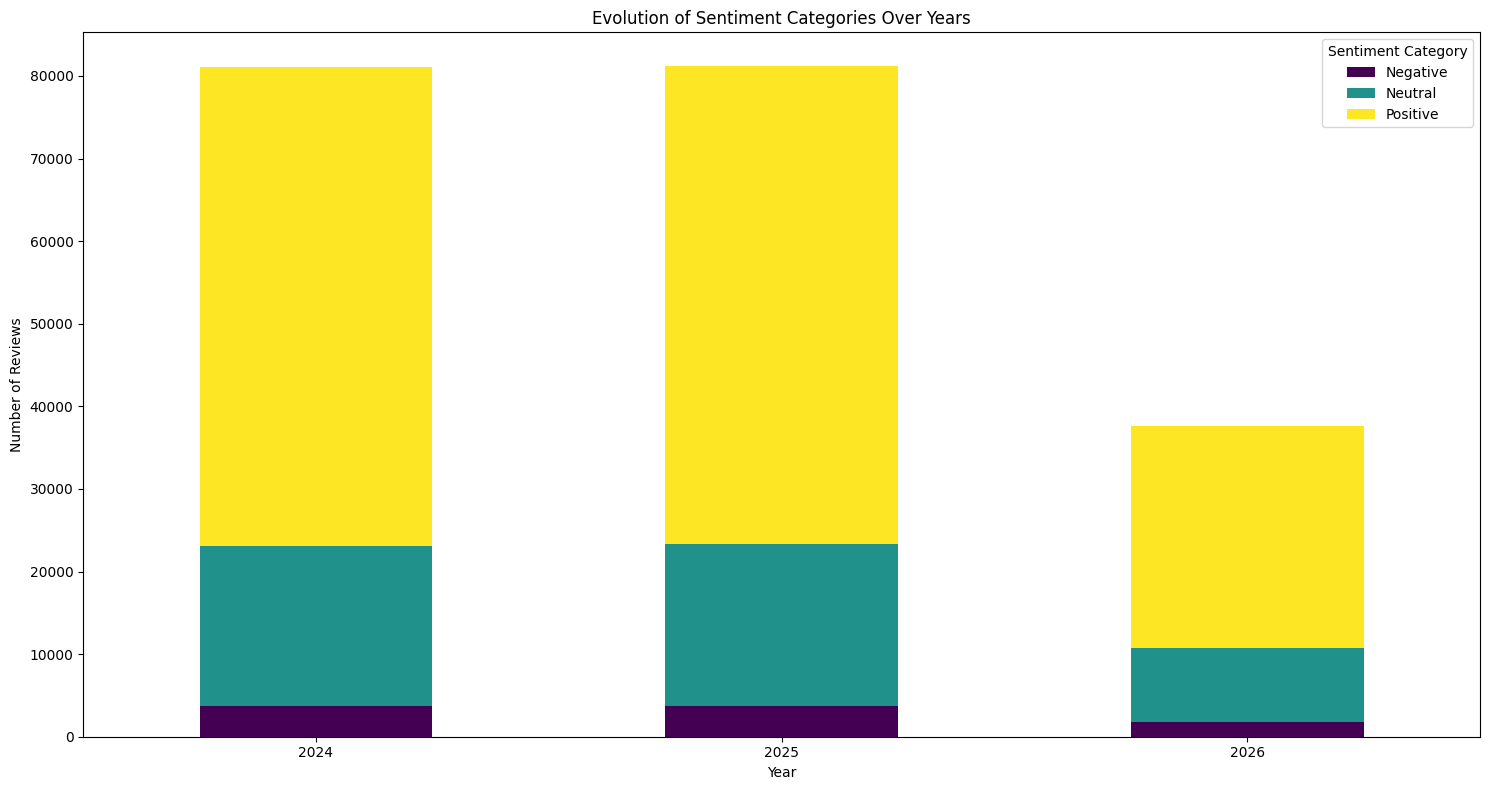

In [64]:
df['year'] = df['review_date'].dt.year

sentiment_category_over_year = df.groupby(['year', 'sentiment_category']).size().unstack(fill_value=0)

# Plotting a stacked bar chart to show the evolution of sentiment categories per year
sentiment_category_over_year[['Negative', 'Neutral', 'Positive']].plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')
plt.title('Evolution of Sentiment Categories Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment Category')
plt.tight_layout()
plt.show()